## Introduction
This project uses Kaggle's LendingClub dataset. Only the accepted loans
file is used, since we aim to understand cases where loans were issued
and either repaid or defaulted, in order to make better lending decisions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_validate,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import(
confusion_matrix,ConfusionMatrixDisplay,
roc_auc_score,RocCurveDisplay,
accuracy_score,classification_report
)

# Data Preparation

### Loading Selected columns

In [31]:
df = pd.read_csv("/content/drive/MyDrive/accepted_2007_to_2018Q4.csv",usecols=['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'emp_length',
                      'grade', 'purpose', 'fico_range_low', 'term', 'home_ownership','loan_status'])
print(df.shape)
df.head()

(2260701, 11)


,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,fico_range_low
0,3600.0,36 months,13.99,C,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,675.0
1,24700.0,36 months,11.99,C,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,715.0
2,20000.0,60 months,10.78,B,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,695.0
3,35000.0,60 months,14.85,C,10+ years,MORTGAGE,110000.0,Current,debt_consolidation,17.06,785.0
4,10400.0,60 months,22.45,F,3 years,MORTGAGE,104433.0,Fully Paid,major_purchase,25.37,695.0


In [34]:
print(df["loan_status"].value_counts())
df.isna().sum()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


,0
loan_amnt,33
term,33
int_rate,33
grade,33
emp_length,146940
home_ownership,33
annual_inc,37
loan_status,33
purpose,33
dti,1744


### Filtering deterministic loan outcomes

In [35]:
deterministic_status =["Fully Paid","Charged Off","Does not meet the credit policy. Status:Fully Paid","Does not meet the credit policy. Status:Charged Off","Default"]
df =df[df["loan_status"].isin(deterministic_status)]
print(len(df))
df.isna().sum()

1348099


,0
loan_amnt,0
term,0
int_rate,0
grade,0
emp_length,78550
home_ownership,0
annual_inc,4
loan_status,0
purpose,0
dti,374


### Missing value handling

In [36]:
df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())
df["dti"] = df["dti"].fillna(df["dti"].median())
df["emp_length"] = df["emp_length"].fillna(df["emp_length"].mode()[0])
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
grade,0
emp_length,0
home_ownership,0
annual_inc,0
loan_status,0
purpose,0
dti,0


In [37]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 1348099 entries, 0 to 2260697
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   loan_amnt       1348099 non-null  float64
 1   term            1348099 non-null  object 
 2   int_rate        1348099 non-null  float64
 3   grade           1348099 non-null  object 
 4   emp_length      1348099 non-null  object 
 5   home_ownership  1348099 non-null  object 
 6   annual_inc      1348099 non-null  float64
 7   loan_status     1348099 non-null  object 
 8   purpose         1348099 non-null  object 
 9   dti             1348099 non-null  float64
 10  fico_range_low  1348099 non-null  float64
dtypes: float64(5), object(6)
memory usage: 123.4+ MB


None

,loan_amnt,int_rate,annual_inc,dti,fico_range_low
count,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06
mean,1.440900e+04,1.324156e+01,7.623771e+04,1.827407e+01,6.961622e+02
std,8.716138e+03,4.765685e+00,6.992264e+04,1.115395e+01,3.185079e+01
min,5.000000e+02,5.310000e+00,0.000000e+00,-1.000000e+00,6.100000e+02
25%,7.975000e+03,9.750000e+00,4.575000e+04,1.179000e+01,6.700000e+02
50%,1.200000e+04,1.274000e+01,6.500000e+04,1.761000e+01,6.900000e+02
75%,2.000000e+04,1.599000e+01,9.000000e+04,2.405000e+01,7.100000e+02
max,4.000000e+04,3.099000e+01,1.099920e+07,9.990000e+02,8.450000e+02


In [38]:
numeric_cols = df.select_dtypes(include=['number']).columns.to_list()
categorical_cols = df.select_dtypes(exclude=['number']).columns.to_list()

# Checking categorical value distributions before encoding
for col in categorical_cols:
    display(df[col].value_counts(normalize=True)*100)

,proportion
term,
36 months,75.899915
60 months,24.100085


,proportion
grade,
B,29.159728
C,28.360158
A,17.446271
D,14.958620
E,6.987024
F,2.396412
G,0.691789


,proportion
emp_length,
10+ years,38.664000
2 years,9.057198
< 1 year,8.051115
3 years,8.001490
1 year,6.590243
5 years,6.255179
4 years,5.990880
6 years,4.664272
8 years,4.510870


,proportion
home_ownership,
MORTGAGE,49.466100
RENT,39.737364
OWN,10.757889
ANY,0.021215
OTHER,0.013500
NONE,0.003931


,proportion
loan_status,
Fully Paid,79.871805
Charged Off,19.921311
Does not meet the credit policy. Status:Fully Paid,0.147467
Does not meet the credit policy. Status:Charged Off,0.056450
Default,0.002967


,proportion
purpose,
debt_consolidation,57.966218
credit_card,21.929027
home_improvement,6.507015
other,5.808253
major_purchase,2.191976
medical,1.158224
small_business,1.155479
car,1.086864
moving,0.706625


### Target Variable Encoding + Ordinal Variable Encoding

In [39]:
for col in ["emp_length", "grade", "term", "loan_status"]:
    df[col] = df[col].astype(str).str.strip()

emp_len_map = {"10+ years":10,"9 years":9,"8 years":8,"7 years":7,
               "6 years":6,"5 years":5,"4 years":4,"3 years":3,
               "2 years":2,"1 year":1,"< 1 year":0}
df["emp_length"]= df["emp_length"].map(emp_len_map)

grade_map ={"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
df["grade"]=df["grade"].map(grade_map)


loan_status_map ={"Fully Paid":0,"Does not meet the credit policy. Status:Fully Paid":0,
                 "Charged Off":1,"Default":1,"Does not meet the credit policy. Status:Charged Off":1}
df["loan_status"]  = df["loan_status"].map(loan_status_map)

term_map = {"36 months":36,"60 months":60}
df["term"]=df["term"].map(term_map)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1348099 entries, 0 to 2260697
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   loan_amnt       1348099 non-null  float64
 1   term            1348099 non-null  int64  
 2   int_rate        1348099 non-null  float64
 3   grade           1348099 non-null  int64  
 4   emp_length      1348099 non-null  int64  
 5   home_ownership  1348099 non-null  object 
 6   annual_inc      1348099 non-null  float64
 7   loan_status     1348099 non-null  int64  
 8   purpose         1348099 non-null  object 
 9   dti             1348099 non-null  float64
 10  fico_range_low  1348099 non-null  float64
dtypes: float64(5), int64(4), object(2)
memory usage: 123.4+ MB


### One-Hot Encoding Features:
Few of the featured did not show binary or ordinal characteristic and hence could not be labelled using map like did before, if done, that feature would imply something else, hence we perform OneHotEncoding here.

We used OneHotEncoding instead of pd.get_dummies() which also does the same thing but OHE is more production appropriate

In [40]:

ohe = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes(exclude='number').columns.tolist()

encoded_data =ohe.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(encoded_data,columns=ohe.get_feature_names_out(categorical_columns))
df = df.reset_index(drop=True)
df = pd.concat([df.drop(columns=categorical_columns),encoded_df],axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348099 entries, 0 to 1348098
Data columns (total 29 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1348099 non-null  float64
 1   term                        1348099 non-null  int64  
 2   int_rate                    1348099 non-null  float64
 3   grade                       1348099 non-null  int64  
 4   emp_length                  1348099 non-null  int64  
 5   annual_inc                  1348099 non-null  float64
 6   loan_status                 1348099 non-null  int64  
 7   dti                         1348099 non-null  float64
 8   fico_range_low              1348099 non-null  float64
 9   home_ownership_ANY          1348099 non-null  float64
 10  home_ownership_MORTGAGE     1348099 non-null  float64
 11  home_ownership_NONE         1348099 non-null  float64
 12  home_ownership_OTHER        1348099 non-null  float64
 1

In [41]:
display(df.head())
df.describe()

,loan_amnt,term,int_rate,grade,emp_length,annual_inc,loan_status,dti,fico_range_low,home_ownership_ANY,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,3600.0,36,13.99,3,10,55000.0,0,5.91,675.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,24700.0,36,11.99,3,10,65000.0,0,16.06,715.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,20000.0,60,10.78,2,10,63000.0,0,10.78,695.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10400.0,60,22.45,6,3,104433.0,0,25.37,695.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11950.0,36,13.44,3,4,34000.0,0,10.20,690.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,loan_amnt,term,int_rate,grade,emp_length,annual_inc,loan_status,dti,fico_range_low,home_ownership_ANY,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
count,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,...,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06,1.348099e+06
mean,1.440900e+04,4.178402e+01,1.324156e+01,2.748368e+00,6.197334e+00,7.623771e+04,1.998073e-01,1.827407e+01,6.961622e+02,2.121506e-04,...,6.507015e-02,5.413549e-03,2.191976e-02,1.158224e-02,7.066247e-03,5.808253e-02,6.943110e-04,1.155479e-02,6.738378e-03,1.743195e-03
std,8.716138e+03,1.026458e+01,4.765685e+00,1.296750e+00,3.705413e+00,6.992264e+04,3.998555e-01,1.115395e+01,3.185079e+01,1.456385e-02,...,2.466497e-01,7.337742e-02,1.464216e-01,1.069958e-01,8.376348e-02,2.338995e-01,2.634064e-02,1.068704e-01,8.181062e-02,4.171520e-02
min,5.000000e+02,3.600000e+01,5.310000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,6.100000e+02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.975000e+03,3.600000e+01,9.750000e+00,2.000000e+00,3.000000e+00,4.575000e+04,0.000000e+00,1.179000e+01,6.700000e+02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.200000e+04,3.600000e+01,1.274000e+01,3.000000e+00,7.000000e+00,6.500000e+04,0.000000e+00,1.761000e+01,6.900000e+02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000e+04,3.600000e+01,1.599000e+01,4.000000e+00,1.000000e+01,9.000000e+04,0.000000e+00,2.405000e+01,7.100000e+02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.000000e+04,6.000000e+01,3.099000e+01,7.000000e+00,1.000000e+01,1.099920e+07,1.000000e+00,9.990000e+02,8.450000e+02,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


/tmp/ipykernel_12877/3709721677.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.boxplot(column=['loan_amnt','int_rate','annual_inc','dti','grade'],by='loan_status',


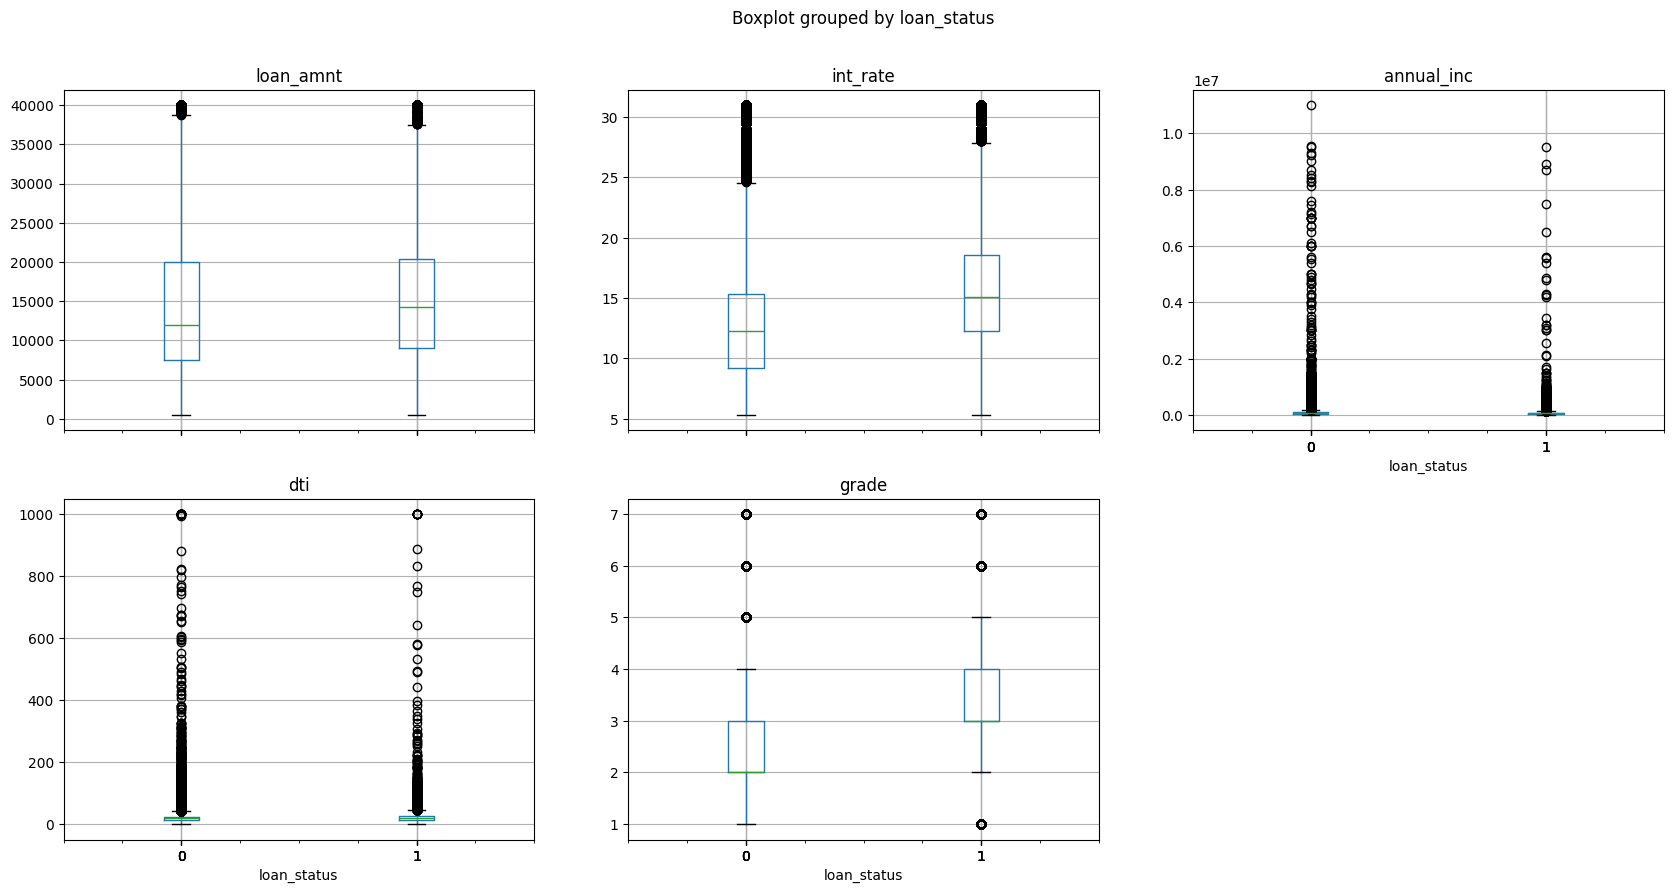

In [42]:
fig,axes = plt.subplots(figsize=(20,10))
df.boxplot(column=['loan_amnt','int_rate','annual_inc','dti','grade'],by='loan_status',
          ax=axes,
          layout = (2,3),
           sharey=False)
plt.show()

<Axes: title={'center': 'Loan Default Split'}, ylabel='count'>

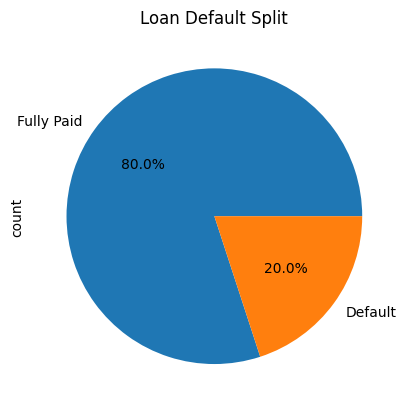

In [43]:
df['loan_status'].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    title="Loan Default Split",
    labels=["Fully Paid","Default"]
)

array([[<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'int_rate'}>],
       [<Axes: title={'center': 'annual_inc'}>,
        <Axes: title={'center': 'dti'}>],
       [<Axes: title={'center': 'grade'}>, <Axes: >]], dtype=object)

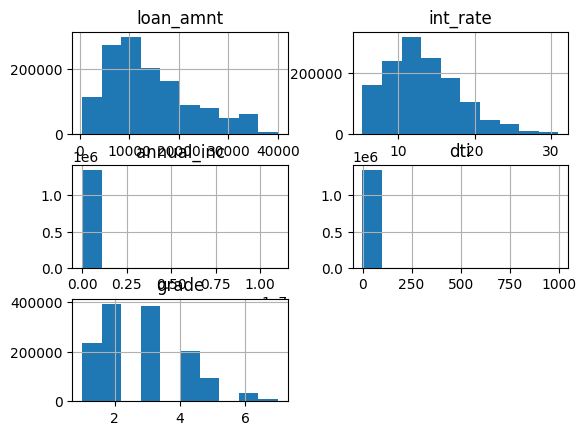

In [ ]:
df.hist(column=['loan_amnt','int_rate','annual_inc','dti','grade'],bins=10)

# Model Training & Evaluation

In [ ]:
y = df['loan_status']
df.drop(columns=['loan_status'],inplace=True)

### Decision Tree - Depth Sweeep (Cross-Validation)

1
3
5
8
12
16
20
25
29


/tmp/ipykernel_12877/2708522690.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


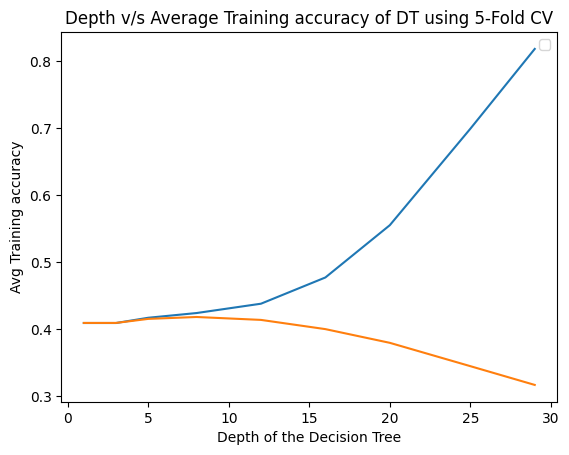

In [ ]:
dt_training_acc_list =[]
dt_testing_acc_list =[]

for d in [1, 3, 5, 8, 12, 16, 20,25,29]:
    dt = DecisionTreeClassifier(criterion="gini",
                                splitter="best",
                                max_depth=d,
                                class_weight='balanced' # High imbalance between class labels would lead to unfair voting hence
                                # weight assigned to ensure fair voting
                               )
    result = cross_validate(dt,X=df,y=y,cv=5,return_train_score=True,
                            scoring="f1",n_jobs=-1)
    dt_training_acc_list.append(np.mean(result["train_score"]))
    dt_testing_acc_list.append(np.mean(result["test_score"]))
    print(d)

plt.plot([1, 3, 5, 8, 12, 16, 20,25,29],dt_training_acc_list)
plt.plot([1, 3, 5, 8, 12, 16, 20,25,29],dt_testing_acc_list)
plt.legend()
plt.xlabel("Depth of the Decision Tree")
plt.ylabel("Avg Training accuracy")
plt.title("Depth v/s Average Training accuracy of DT using 5-Fold CV")
plt.show()


# max_depth decision:
The exercise before this show that the Decision Tree performs best for max_depth = 8 and then later the F1-score drops, hence it was decided that 8 is an appropriate max_depth for this case

### Model Training + Confusion matrix + Metric Evaluation

              precision    recall  f1-score   support

           0       0.88      0.64      0.74    215748
           1       0.31      0.66      0.42     53872

    accuracy                           0.64    269620
   macro avg       0.60      0.65      0.58    269620
weighted avg       0.77      0.64      0.68    269620



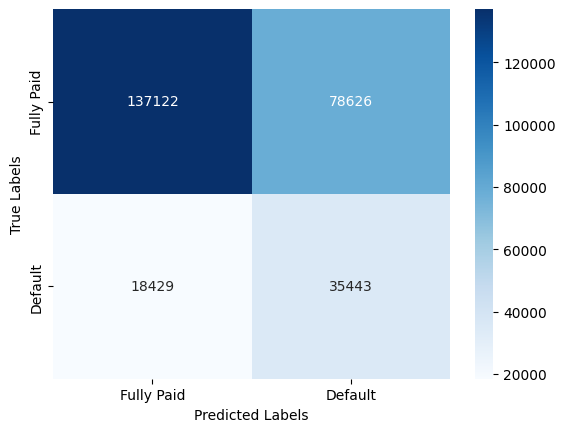

In [ ]:
dt = DecisionTreeClassifier(criterion="gini",
                                splitter="best",
                                max_depth=8,
                                class_weight='balanced',
                            random_state=42)

X_train,X_test,y_train,y_test = train_test_split(df,y,test_size=0.2,stratify=y,random_state=42)
dt = dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
#ConfusionMatrixDisplay(cm).plot()
print(classification_report(y_test,y_pred))

sns.heatmap(cm,annot=True,fmt="d",
            cmap="Blues",
             xticklabels=["Fully Paid", "Default"],
            yticklabels=["Fully Paid", "Default"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Feature Scaling:
Decision Trees are able to work on unscaled data as they make comparison based decision , For KNN this is not true
we need to scale the data because KNN is a distance based decision algorithm so features with high values may impact
the distance more if left unscaled so we scale the input features.

Standard Scaler does not guarantee a range of value but makes sure it shifts the mean to 0 and standard deviation to 1, which sets them all on a comparable scale efficient for KNN

In [ ]:
scaler = StandardScaler()
knn_X_train = scaler.fit_transform(X_train)
knn_X_test = scaler.transform(X_test)

# n_neighbors decision:
The value was selected randomly because high value of data along with speed complexity makes it unfeasable to perform experimentation for value of n_neighbors.

Note: there exists a possibility that for different value of n_neighbors, the model would perform better

### K-Nearest-Neighbors - Model Training

In [ ]:
knn = KNeighborsClassifier(n_neighbors=11,weights='uniform')
knn.fit(knn_X_train,y_train)
knn_y_pred = knn.predict(knn_X_test)


### Confusion Matrix + Metrics Evaluation

              precision    recall  f1-score   support

           0       0.81      0.96      0.88    215748
           1       0.42      0.13      0.19     53872

    accuracy                           0.79    269620
   macro avg       0.62      0.54      0.54    269620
weighted avg       0.74      0.79      0.74    269620



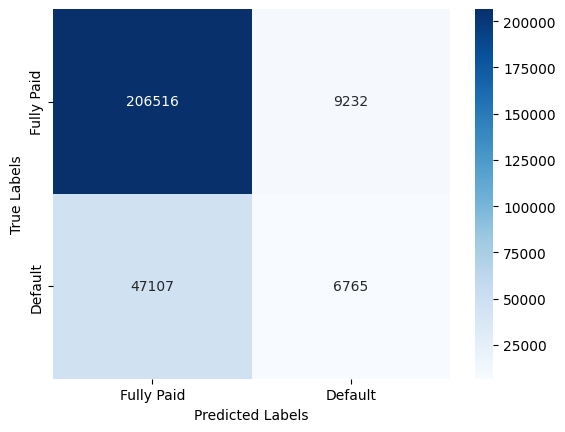

In [ ]:
print(classification_report(y_test,knn_y_pred))

cm = confusion_matrix(y_test,knn_y_pred)
sns.heatmap(cm,annot=True,fmt="d",
            cmap="Blues",
             xticklabels=["Fully Paid", "Default"],
            yticklabels=["Fully Paid", "Default"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### ROC-AUC curve comparison

In [26]:
dt_proba = dt.predict_proba(X_test)[:,1]
knn_proba = knn.predict_proba(knn_X_test)[:,1]


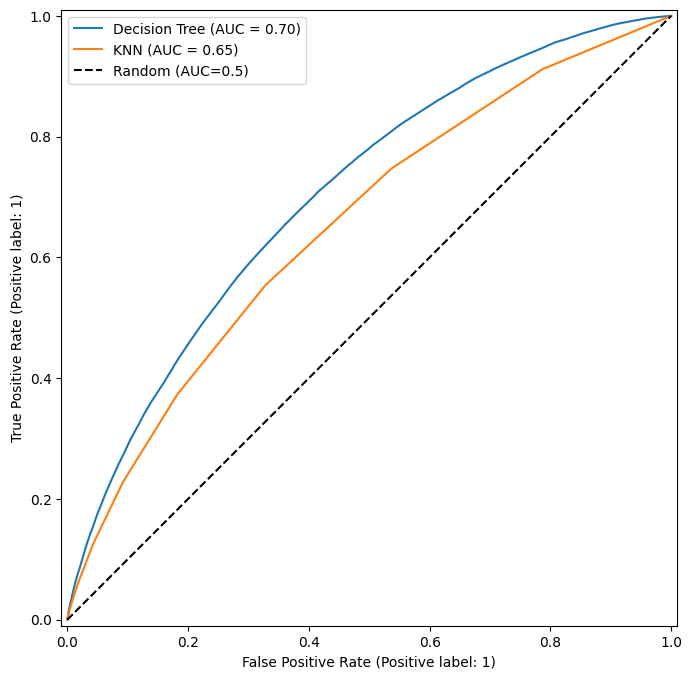

In [27]:
fig,ax = plt.subplots(figsize=(10,8))
RocCurveDisplay.from_predictions(y_test,dt_proba,name="Decision Tree",ax=ax)
RocCurveDisplay.from_predictions(y_test,knn_proba,name="KNN",ax=ax)
plt.plot([0,1],[0,1],'k--',label="Random (AUC=0.5)")
plt.legend()
plt.show()

In [44]:
print(f" ROC-AUC score for Decision Tree : {roc_auc_score(y_test,dt_proba)}")
print(f" ROC-AUC score for KNN : {roc_auc_score(y_test,knn_proba)}")

 ROC-AUC score for Decision Tree : 0.7039930409721207
 ROC-AUC score for KNN : 0.6531717791677328


### Conclusion:

Due to heavy imbalance between class labels, both classifiers struggle on
the minority "Default" class. The Decision Tree achieves substantially
higher Recall (0.66 vs 0.13) — catching roughly 5x more actual defaults
than KNN — and a higher AUC (0.704 vs 0.653). KNN does have higher
Precision (0.42 vs 0.31), meaning its positive predictions are more often
correct, but it misses the vast majority of real defaults.

**Why Recall matters more than Precision for this use case:** A False
Negative (predicting "Fully Paid" when the loan actually defaults) means
the lender approves a risky loan and loses the principal amount. A False
Positive (predicting "Default" when the loan is actually fine) only costs
a missed lending opportunity — a smaller, recoverable loss. Since missing
a real default is far more costly than a false alarm, Recall is the more
important metric to optimize here, making the Decision Tree the stronger
model despite its lower Precision.

**Recommendation:** The Decision Tree (max_depth=8, class_weight='balanced')
is the better choice for a lender, given its substantially higher Recall
and AUC on the Default class. Both models still leave meaningful room for
improvement, since neither achieves strong enough Recall to confidently
catch the majority of risky loans.